[[0.043082142857142854, np.float64(53.43666163), np.float64(-2.22416998)], [0.0523875, np.float64(53.45156846), np.float64(-2.22233599)], [0.051239999999999994, np.float64(53.45335535), np.float64(-2.2233241)], [0.01, 53.45927628199057, -2.2276463370981574], [0.01, 53.4645870298434, -2.2320827813567172]]
[184, 21, 72, 65]
[0, 184, 205] [0.043082142857142854, 0.0523875, 0.051239999999999994]
Travel time: 23.17 min
Travel time: 23.20 min
Travel time: 23.24 min
Travel time: 23.26 min
Travel time: 23.27 min
Travel time: 23.29 min
Travel time: 23.29 min
Travel time: 23.29 min
Travel time: 23.27 min
Travel time: 23.27 min
Travel time: 23.26 min
Travel time: 23.22 min
Travel time: 23.20 min
Travel time: 23.17 min
Travel time: 23.13 min
Travel time: 23.09 min
Travel time: 23.04 min
Travel time: 22.99 min
Travel time: 22.93 min
Travel time: 22.88 min
Travel time: 22.81 min
Travel time: 22.75 min
Travel time: 22.68 min
Travel time: 22.61 min
Travel time: 22.52 min
Travel time: 22.45 min
Travel t

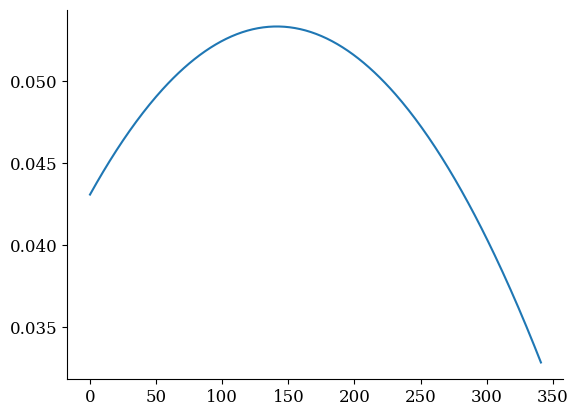

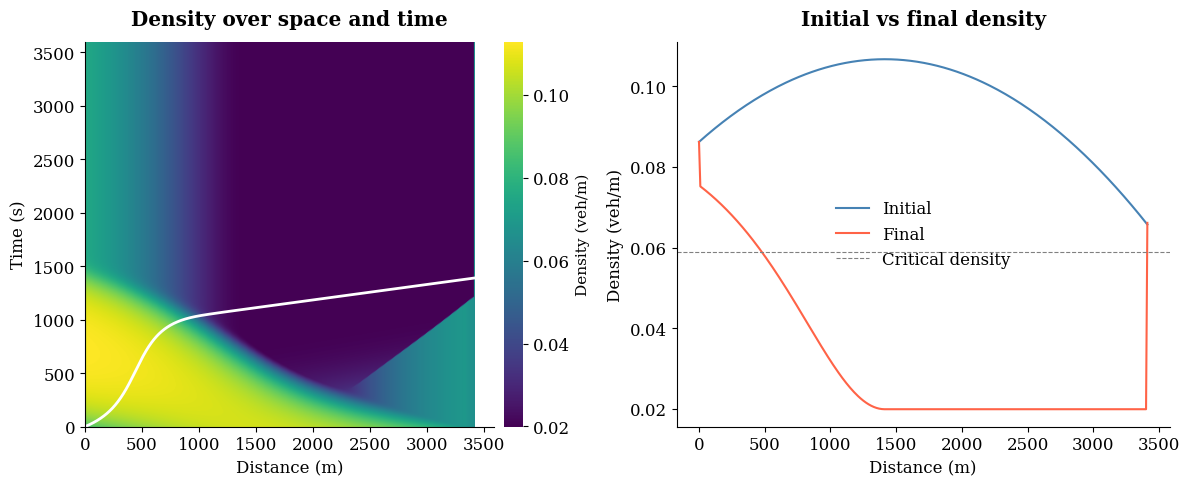

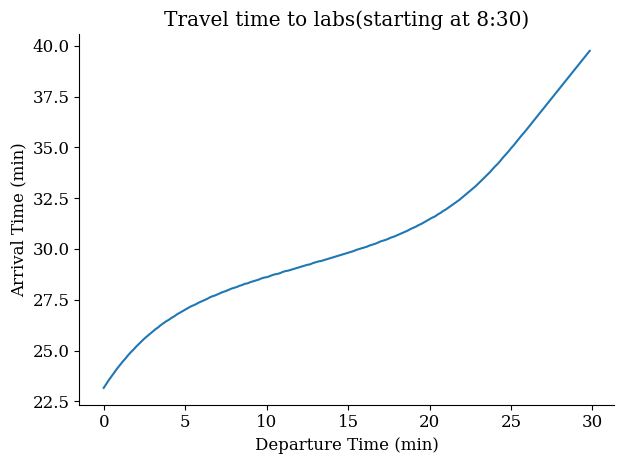

In [23]:
import sys
import os

from numpy.ma.core import arange

sys.path.append(os.path.abspath('..'))

# print("Python path:", sys.path)
# print("Parent folder contents:", os.listdir('..'))
# print("Current folder:", os.getcwd())

import inspect
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from src.lwr_model import density_array_polynomial, density_array_linear
from src.lwr_model import FREE_SPEEDS, CELL_SIZE
from src.lwr_model.CTM import CTM_model

# --- Real world density ---
whole_density_arr, _ = density_array_polynomial()
# --- Model setup ---
density_init = np.array(whole_density_arr) *2
N = len(density_init)
cell_widths = np.full(N, CELL_SIZE)

v_free = min(FREE_SPEEDS.values()) * (1000/3600)
jam_density = 1/8.5 # jam density v important for Greenshields
max_flow = v_free * jam_density / 5
inlet_density = density_init[0]
simulation_time = 60*60

# --- Run ---
model = CTM_model(cell_widths, density_init, jam_density, max_flow, v_free)
model.run(inlet_density=inlet_density, total_time=simulation_time)

# --- Plot ---

plt.plot(whole_density_arr)

history = np.array(model.history)
distance = np.arange(N) * CELL_SIZE

mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(
    history,
    aspect='auto',
    origin='lower',
    extent=[0, N * CELL_SIZE, 0, len(history) * model.step_width],
    cmap='viridis'
)
cbar = fig.colorbar(im, ax=axes[0], pad=0.02)
cbar.set_label('Density (veh/m)', fontsize=11)
cbar.outline.set_visible(False)
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Density over space and time', fontweight='bold', pad=12)

# Initial vs final
axes[1].plot(distance, history[0], label='Initial', color='steelblue', linewidth=1.5)
axes[1].plot(distance, history[-1], label='Final', color='tomato', linewidth=1.5)
axes[1].axhline(jam_density / 2, color='grey', linestyle='--', linewidth=0.8, label='Critical density')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Density (veh/m)')
axes[1].set_title('Initial vs final density', fontweight='bold', pad=12)
axes[1].legend(frameon=False)


# --- Travel time ---
time_arr = []
total_trajectory_x=[]
total_trajectory_t=[]
for i in range(0,1800, 10):
    travel,trajectory_x,trajectory_t = model.travel_time(start_cell=0, end_cell=N-1, start_time=i)
    total_trajectory_x.append(trajectory_x)
    total_trajectory_t.append(trajectory_t)
    time_arr.append((i + travel) / 60)
    print(f"Travel time: {travel/60:.2f} min" if travel else "Vehicle did not reach end within simulation")
axes[0].plot(total_trajectory_x[0], total_trajectory_t[0], color='white', linewidth=2, label='Vehicle trajectory')
fig,ax=plt.subplots(1)
ax.plot(np.arange(0,1800, 10)/ 60, time_arr)
ax.set_title('Travel time to labs(starting at 8:30)')
ax.set_xlabel('Departure Time (min)')
ax.set_ylabel('Arrival Time (min)')
plt.tight_layout()
plt.show()